In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [ ]:
class PEMMSolver:
  def __init__(self, N, totalLength, radius):
    self.N = N
    self.totalLength = totalLength
    self.radius = radius
    self.a = np.empty(self.N)

  def fillZ(self):
    Z = np.empty((self.N,self.N))
    elementLength = self.totalLength/self.N
    halfLength = elementLength/2
    for m in range(self.N):
      for n in range(self.N):
        l = abs(n-m) * elementLength
        forwardD = l + halfLength
        backwardD = l - halfLength
        if (m==n):
          Z[m][n] = 2*math.log(
              (halfLength + math.sqrt(self.radius**2 + halfLength**2))/self.radius
          )
        elif (abs(m-n) <= 2):
          Z[m][n] = math.log(
              (forwardD + math.sqrt(forwardD**2 + self.radius**2))\
              /(backwardD + math.sqrt(backwardD**2 + self.radius**2))
          )
        else:
          Z[m][n] = math.log(forwardD/backwardD)

    return Z

  def solve(self):
    Z = self.fillZ()
    RHS = 1.11e-10*np.ones((self.N))
    self.a = np.dot(np.linalg.inv(Z), RHS)
    return self.a

  def plotChargeDistribution(self):
    aIndices = np.linspace(0, self.N, self.N)
    x = self.totalLength/self.N*aIndices
    plt.plot(x, self.a)

  def solveAndPlotChargeDistribution(self):
    self.solve()
    self.plotChargeDistribution()

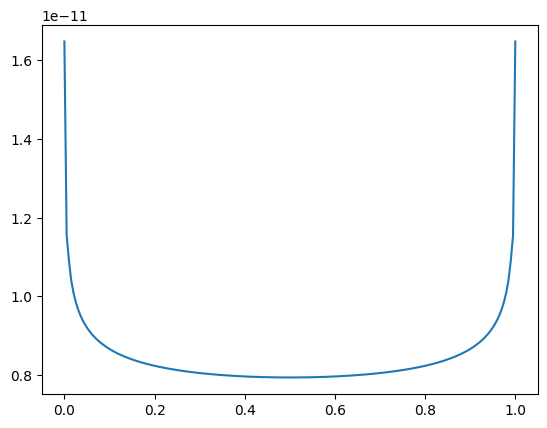

In [ ]:
solver = PEMMSolver(200, 1, 0.001)
solver.solveAndPlotChargeDistribution()